### **A1 - Predicting Car Price**
#### **Name:** Dakchhyeta Bade Shretha
#### **Student ID:** 126671

# **TASK 1: Preparing the datasets**

In [3]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')

## **Loading the Dataset**

In [2]:
df = pd.read_csv('/content/Cars.csv')

In [4]:
df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.4 kmpl,1248 CC,74 bhp,190Nm@ 2000rpm,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14 kmpl,1498 CC,103.52 bhp,250Nm@ 1500-2500rpm,5.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.7 kmpl,1497 CC,78 bhp,"12.7@ 2,700(kgm@ rpm)",5.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.0 kmpl,1396 CC,90 bhp,22.4 kgm at 1750-2750rpm,5.0
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.1 kmpl,1298 CC,88.2 bhp,"11.5@ 4,500(kgm@ rpm)",5.0


In [5]:
df.shape

(8128, 13)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8128 entries, 0 to 8127
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   name           8128 non-null   object 
 1   year           8128 non-null   int64  
 2   selling_price  8128 non-null   int64  
 3   km_driven      8128 non-null   int64  
 4   fuel           8128 non-null   object 
 5   seller_type    8128 non-null   object 
 6   transmission   8128 non-null   object 
 7   owner          8128 non-null   object 
 8   mileage        7907 non-null   object 
 9   engine         7907 non-null   object 
 10  max_power      7913 non-null   object 
 11  torque         7906 non-null   object 
 12  seats          7907 non-null   float64
dtypes: float64(1), int64(3), object(9)
memory usage: 825.6+ KB


In [7]:
df.describe()

,year,selling_price,km_driven,seats
count,8128.000000,8.128000e+03,8.128000e+03,7907.000000
mean,2013.804011,6.382718e+05,6.981951e+04,5.416719
std,4.044249,8.062534e+05,5.655055e+04,0.959588
min,1983.000000,2.999900e+04,1.000000e+00,2.000000
25%,2011.000000,2.549990e+05,3.500000e+04,5.000000
50%,2015.000000,4.500000e+05,6.000000e+04,5.000000
75%,2017.000000,6.750000e+05,9.800000e+04,5.000000
max,2020.000000,1.000000e+07,2.360457e+06,14.000000


In [8]:
df.columns

Index(['name', 'year', 'selling_price', 'km_driven', 'fuel', 'seller_type',
       'transmission', 'owner', 'mileage', 'engine', 'max_power', 'torque',
       'seats'],
      dtype='object')

## **Dataset Preparation**

Before cleaning the dataset, the unique values of important categorical features are inspected.

In [9]:
print("Owner categories:")
print(df['owner'].unique())

print("\nFuel categories:")
print(df['fuel'].unique())

Owner categories:
['First Owner' 'Second Owner' 'Third Owner' 'Fourth & Above Owner'
 'Test Drive Car']

Fuel categories:
['Diesel' 'Petrol' 'LPG' 'CNG']


#### **Mapping the Owner Feature**

The categorical values in the `owner` column are mapped to numerical values as specified in the assignment.

In [10]:
owner_map = {
    'First Owner': 1,
    'Second Owner': 2,
    'Third Owner': 3,
    'Fourth & Above Owner': 4,
    'Test Drive Car': 5
}

df['owner'] = df['owner'].map(owner_map)

In [11]:
df['owner'].unique()

array([1, 2, 3, 4, 5])

#### **Removing Test Drive Cars**

Test Drive Cars are removed because their selling prices are unusually high compared with normal used cars and could distort the model.

In [12]:
df = df[df['owner'] != 5]

In [13]:
df['owner'].unique()

array([1, 2, 3, 4])

In [14]:
df.shape

(8123, 13)

#### **Removing CNG and LPG Fuel Types**

CNG and LPG vehicles are removed because their mileage is measured using `km/kg`, which is different from the `kmpl` measurement used by Diesel and Petrol vehicles.

In [15]:
df = df[~df['fuel'].isin(['CNG', 'LPG'])]

In [16]:
df['fuel'].unique()

array(['Diesel', 'Petrol'], dtype=object)

In [17]:
df.shape

(8028, 13)

In [18]:
df['mileage'].head()

,mileage
0,23.4 kmpl
1,21.14 kmpl
2,17.7 kmpl
3,23.0 kmpl
4,16.1 kmpl


#### **Cleaning the Mileage Feature**

The `kmpl` unit is removed from the `mileage` column and the remaining value is converted into numerical format.

In [19]:
df['mileage'] = df['mileage'].str.split().str[0]
df['mileage'] = pd.to_numeric(df['mileage'], errors='coerce')

In [20]:
df['mileage'].head()

,mileage
0,23.40
1,21.14
2,17.70
3,23.00
4,16.10


In [21]:
df['mileage'].dtype

dtype('float64')

In [22]:
df['engine'].head()

,engine
0,1248 CC
1,1498 CC
2,1497 CC
3,1396 CC
4,1298 CC


#### **Cleaning the Engine Feature**

The `CC` unit is removed from the `engine` column and the remaining values are converted into numerical format.

In [23]:
df['engine'] = df['engine'].str.split().str[0]
df['engine'] = pd.to_numeric(df['engine'], errors='coerce')

In [24]:
df['engine'].head()

,engine
0,1248.0
1,1498.0
2,1497.0
3,1396.0
4,1298.0


In [26]:
df['max_power'].head()

,max_power
0,74 bhp
1,103.52 bhp
2,78 bhp
3,90 bhp
4,88.2 bhp


#### **Cleaning the Maximum Power Feature**

The unit from the `max_power` column is removed and the remaining values are converted into numerical format.

In [27]:
df['max_power'] = df['max_power'].str.split().str[0]
df['max_power'] = pd.to_numeric(df['max_power'], errors='coerce')

In [28]:
df['max_power'].head()

,max_power
0,74.00
1,103.52
2,78.00
3,90.00
4,88.20


#### **Extracting the Car Brand**

The `name` column contains the full name and model of each vehicle. Only the first word is retained as the car `brand`, as required by the assignment.

In [29]:
df['brand'] = df['name'].str.split().str[0]

In [30]:
df[['name', 'brand']].head()

,name,brand
0,Maruti Swift Dzire VDI,Maruti
1,Skoda Rapid 1.5 TDI Ambition,Skoda
2,Honda City 2017-2020 EXi,Honda
3,Hyundai i20 Sportz Diesel,Hyundai
4,Maruti Swift VXI BSIII,Maruti


In [31]:
df.drop(columns=['name'], inplace=True) #dropping the column name as we have 'brand'

In [32]:
df.columns

Index(['year', 'selling_price', 'km_driven', 'fuel', 'seller_type',
       'transmission', 'owner', 'mileage', 'engine', 'max_power', 'torque',
       'seats', 'brand'],
      dtype='object')

#### **Dropping the Torque Feature**

The `torque` feature is removed as instructed in the assignment because it will not be used by the company for price prediction.

In [33]:
df.drop(columns=['torque'], inplace=True)

In [34]:
df.columns

Index(['year', 'selling_price', 'km_driven', 'fuel', 'seller_type',
       'transmission', 'owner', 'mileage', 'engine', 'max_power', 'seats',
       'brand'],
      dtype='object')

In [35]:
df.head() #Verifing the cleaned dataset

,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,seats,brand
0,2014,450000,145500,Diesel,Individual,Manual,1,23.40,1248.0,74.00,5.0,Maruti
1,2014,370000,120000,Diesel,Individual,Manual,2,21.14,1498.0,103.52,5.0,Skoda
2,2006,158000,140000,Petrol,Individual,Manual,3,17.70,1497.0,78.00,5.0,Honda
3,2010,225000,127000,Diesel,Individual,Manual,1,23.00,1396.0,90.00,5.0,Hyundai
4,2007,130000,120000,Petrol,Individual,Manual,1,16.10,1298.0,88.20,5.0,Maruti


In [36]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8028 entries, 0 to 8127
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   year           8028 non-null   int64  
 1   selling_price  8028 non-null   int64  
 2   km_driven      8028 non-null   int64  
 3   fuel           8028 non-null   object 
 4   seller_type    8028 non-null   object 
 5   transmission   8028 non-null   object 
 6   owner          8028 non-null   int64  
 7   mileage        7814 non-null   float64
 8   engine         7814 non-null   float64
 9   max_power      7820 non-null   float64
 10  seats          7814 non-null   float64
 11  brand          8028 non-null   object 
dtypes: float64(4), int64(4), object(4)
memory usage: 815.3+ KB


In [37]:
df.shape

(8028, 12)

In [38]:
df.reset_index(drop=True, inplace=True) #cleaning empty gaps in the rows

In [39]:
df.head()

,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,seats,brand
0,2014,450000,145500,Diesel,Individual,Manual,1,23.40,1248.0,74.00,5.0,Maruti
1,2014,370000,120000,Diesel,Individual,Manual,2,21.14,1498.0,103.52,5.0,Skoda
2,2006,158000,140000,Petrol,Individual,Manual,3,17.70,1497.0,78.00,5.0,Honda
3,2010,225000,127000,Diesel,Individual,Manual,1,23.00,1396.0,90.00,5.0,Hyundai
4,2007,130000,120000,Petrol,Individual,Manual,1,16.10,1298.0,88.20,5.0,Maruti


In [40]:
df.tail()

,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,seats,brand
8023,2013,320000,110000,Petrol,Individual,Manual,1,18.50,1197.0,82.85,5.0,Hyundai
8024,2007,135000,119000,Diesel,Individual,Manual,4,16.80,1493.0,110.00,5.0,Hyundai
8025,2009,382000,120000,Diesel,Individual,Manual,1,19.30,1248.0,73.90,5.0,Maruti
8026,2013,290000,25000,Diesel,Individual,Manual,1,23.57,1396.0,70.00,5.0,Tata
8027,2013,290000,25000,Diesel,Individual,Manual,1,23.57,1396.0,70.00,5.0,Tata


## **Exploratory Data Analysis**

Before building the model, the cleaned dataset is explored to understand missing values, distributions, and relationships between features.

In [41]:
df.isnull().sum()

,0
year,0
selling_price,0
km_driven,0
fuel,0
seller_type,0
transmission,0
owner,0
mileage,214
engine,214
max_power,208


#### **Distribution of Selling Price**

The distribution of `selling_price` is examined to understand the range and skewness of car prices.

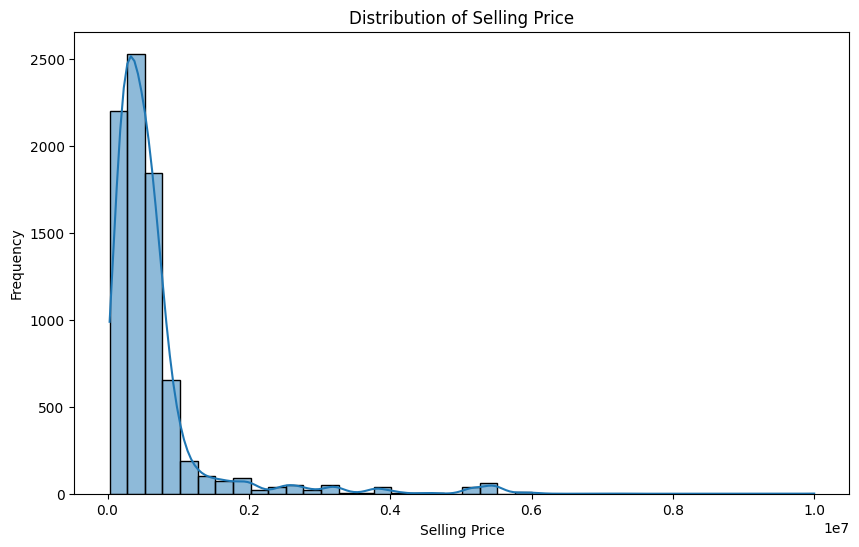

In [42]:
plt.figure(figsize=(10, 6))

sns.histplot(df['selling_price'], bins=40, kde=True)

plt.title('Distribution of Selling Price')
plt.xlabel('Selling Price')
plt.ylabel('Frequency')

plt.show()

The selling price distribution is highly right-skewed. Most vehicles are concentrated in the lower price range, while a small number of expensive vehicles create a long right tail. Therefore, a log transformation will later be applied to the target variable to reduce skewness and improve model stability.

#### **Year vs Selling Price**

This plot examines whether newer cars tend to have higher selling prices.

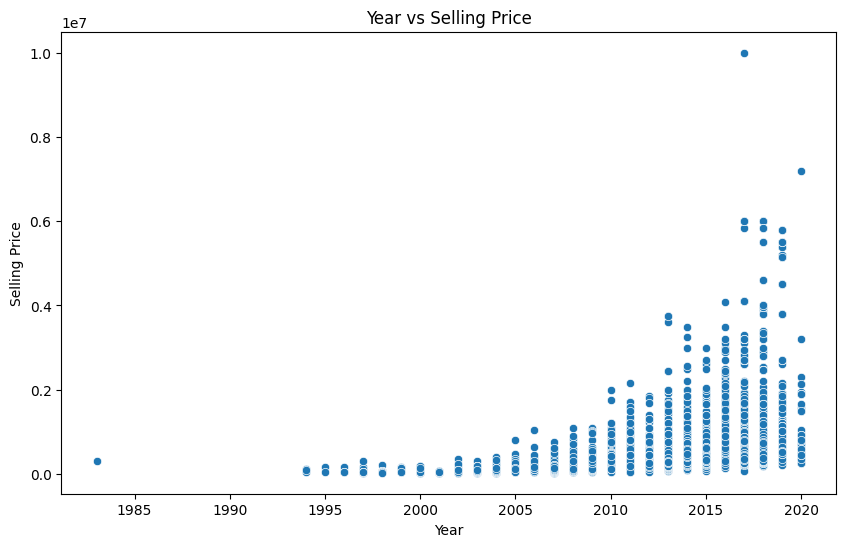

In [43]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x='year',
    y='selling_price'
)

plt.title('Year vs Selling Price')
plt.xlabel('Year')
plt.ylabel('Selling Price')

plt.show()

#### **Maximum Power vs Selling Price**

This plot examines the relationship between a vehicle's maximum power and its selling price.

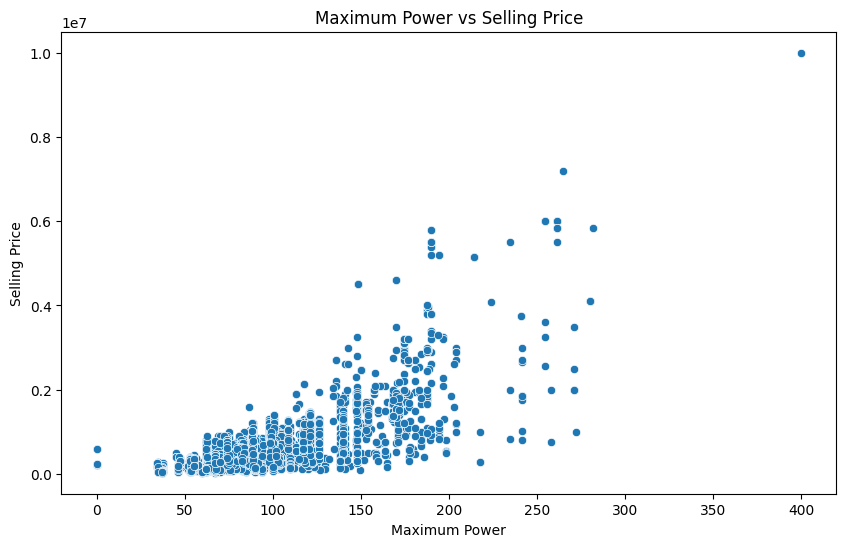

In [44]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x='max_power',
    y='selling_price'
)

plt.title('Maximum Power vs Selling Price')
plt.xlabel('Maximum Power')
plt.ylabel('Selling Price')

plt.show()

### **Encoding Categorical Features**

The categorical features `brand`, `fuel`, `seller_type`, and `transmission` are converted into numerical values using Label Encoding so that they can be used by the machine learning model.

In [45]:
from sklearn.preprocessing import LabelEncoder

# Initialize Label Encoders
label_encoder_brand = LabelEncoder()
label_encoder_fuel = LabelEncoder()
label_encoder_seller_type = LabelEncoder()
label_encoder_transmission = LabelEncoder()

# Encode categorical features
df['brand'] = label_encoder_brand.fit_transform(df['brand'])
df['fuel'] = label_encoder_fuel.fit_transform(df['fuel'])
df['seller_type'] = label_encoder_seller_type.fit_transform(df['seller_type'])
df['transmission'] = label_encoder_transmission.fit_transform(df['transmission'])

# Store the original brand names for later use
original_brands = label_encoder_brand.classes_.tolist()

In [46]:
df.head()

,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,seats,brand
0,2014,450000,145500,0,1,1,1,23.40,1248.0,74.00,5.0,20
1,2014,370000,120000,0,1,1,2,21.14,1498.0,103.52,5.0,27
2,2006,158000,140000,1,1,1,3,17.70,1497.0,78.00,5.0,10
3,2010,225000,127000,0,1,1,1,23.00,1396.0,90.00,5.0,11
4,2007,130000,120000,1,1,1,1,16.10,1298.0,88.20,5.0,20


In [47]:
print("Brand classes:", label_encoder_brand.classes_)
print("Fuel classes:", label_encoder_fuel.classes_)
print("Seller type classes:", label_encoder_seller_type.classes_)
print("Transmission classes:", label_encoder_transmission.classes_)

Brand classes: ['Ambassador' 'Ashok' 'Audi' 'BMW' 'Chevrolet' 'Daewoo' 'Datsun' 'Fiat'
 'Force' 'Ford' 'Honda' 'Hyundai' 'Isuzu' 'Jaguar' 'Jeep' 'Kia' 'Land'
 'Lexus' 'MG' 'Mahindra' 'Maruti' 'Mercedes-Benz' 'Mitsubishi' 'Nissan'
 'Opel' 'Peugeot' 'Renault' 'Skoda' 'Tata' 'Toyota' 'Volkswagen' 'Volvo']
Fuel classes: ['Diesel' 'Petrol']
Seller type classes: ['Dealer' 'Individual' 'Trustmark Dealer']
Transmission classes: ['Automatic' 'Manual']


In [48]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8028 entries, 0 to 8027
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   year           8028 non-null   int64  
 1   selling_price  8028 non-null   int64  
 2   km_driven      8028 non-null   int64  
 3   fuel           8028 non-null   int64  
 4   seller_type    8028 non-null   int64  
 5   transmission   8028 non-null   int64  
 6   owner          8028 non-null   int64  
 7   mileage        7814 non-null   float64
 8   engine         7814 non-null   float64
 9   max_power      7820 non-null   float64
 10  seats          7814 non-null   float64
 11  brand          8028 non-null   int64  
dtypes: float64(4), int64(8)
memory usage: 752.8 KB


### **Saving the Encoded Dataset**

The cleaned and encoded dataset is saved as a CSV file so that it can be reused later without repeating the initial cleaning steps.

In [49]:
df.to_csv('/content/le_cars_data.csv', index=False)

### **Univariate Analysis**

Distribution plots are used to examine the individual distributions of the numerical features in the cleaned dataset.

In [50]:
df_copy = df.loc[:, df.columns != 'selling_price']

num_cols = df_copy.select_dtypes(include=['int64', 'float64'])

num_cols.columns

Index(['year', 'km_driven', 'fuel', 'seller_type', 'transmission', 'owner',
       'mileage', 'engine', 'max_power', 'seats', 'brand'],
      dtype='object')

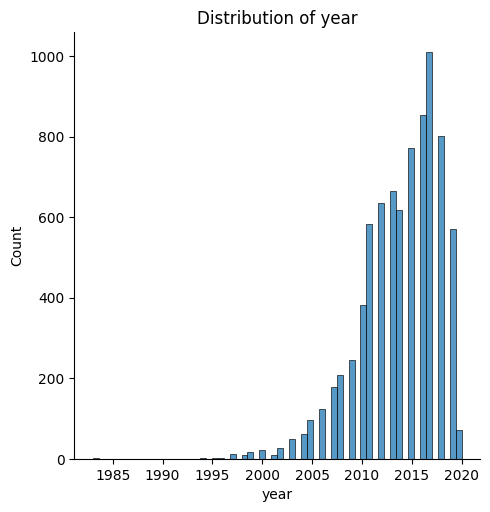

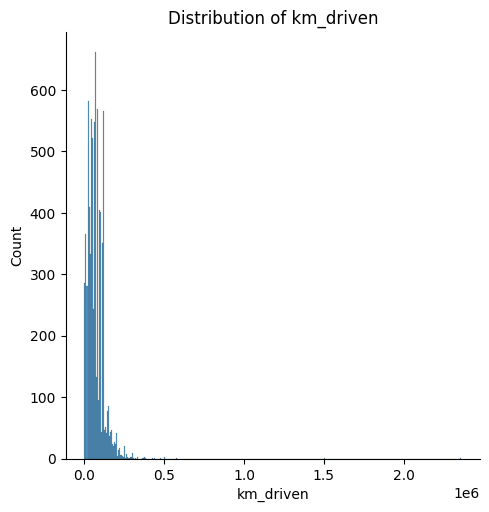

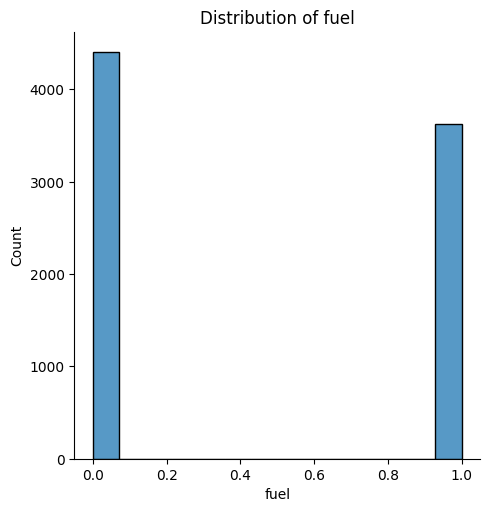

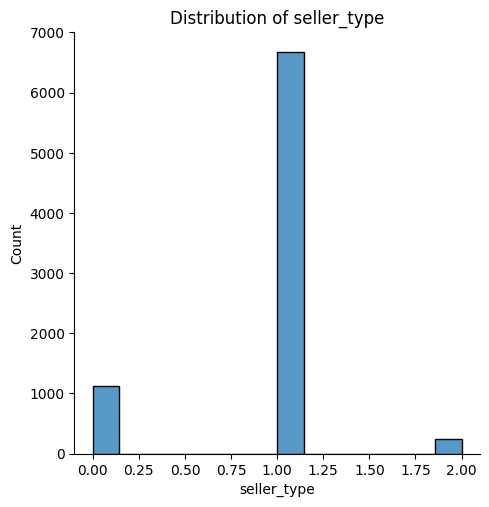

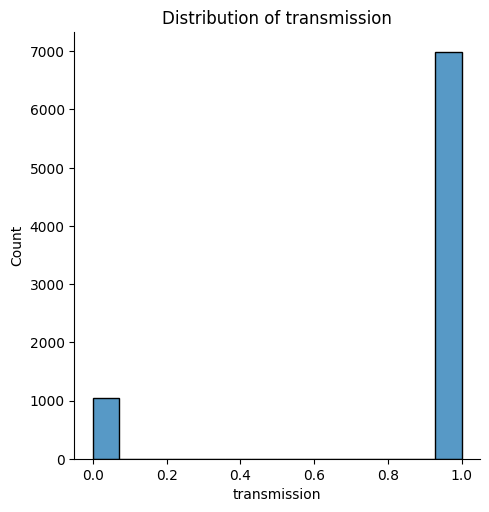

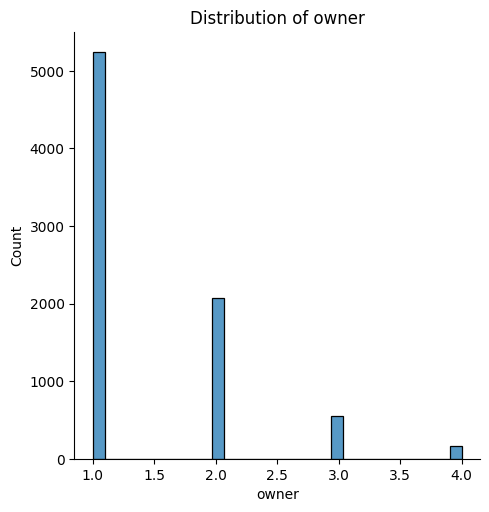

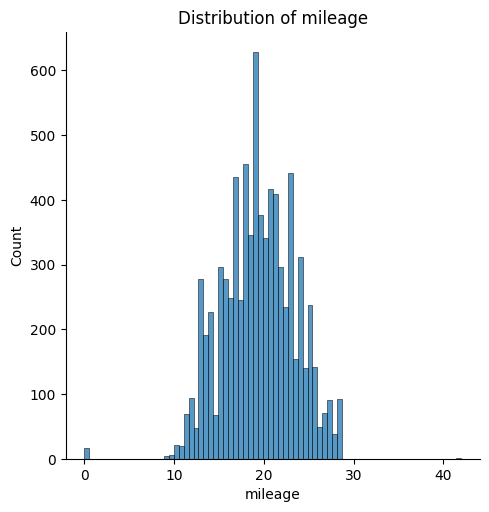

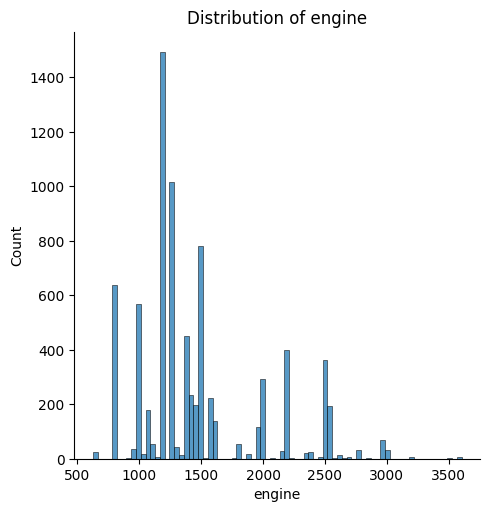

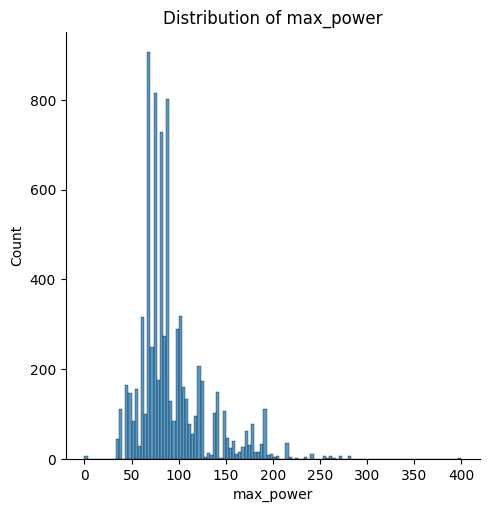

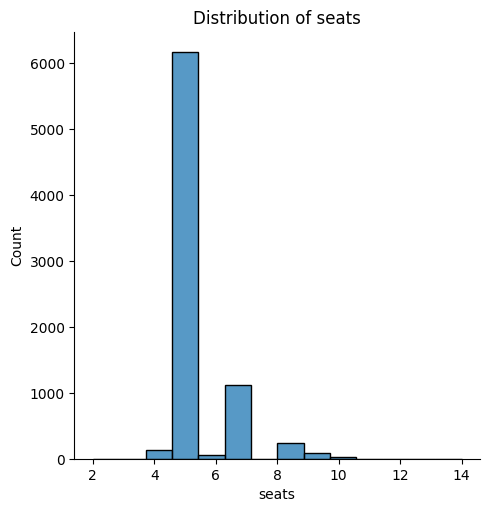

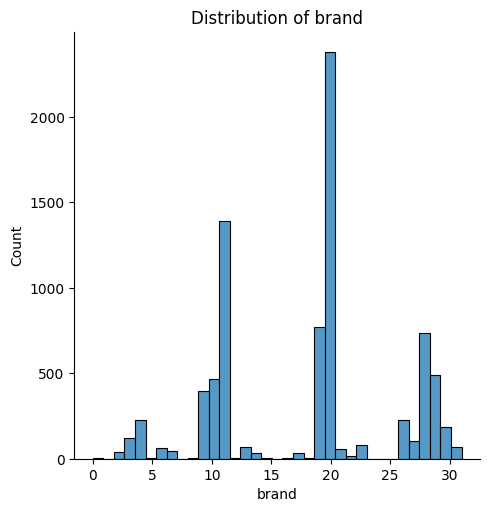

In [51]:
for col in num_cols.columns:
    sns.displot(df, x=col)
    plt.title(f'Distribution of {col}')
    plt.show()

### **Multivariate Analysis**

Scatter plots are used to examine the relationships between individual features and the target variable `selling_price`.

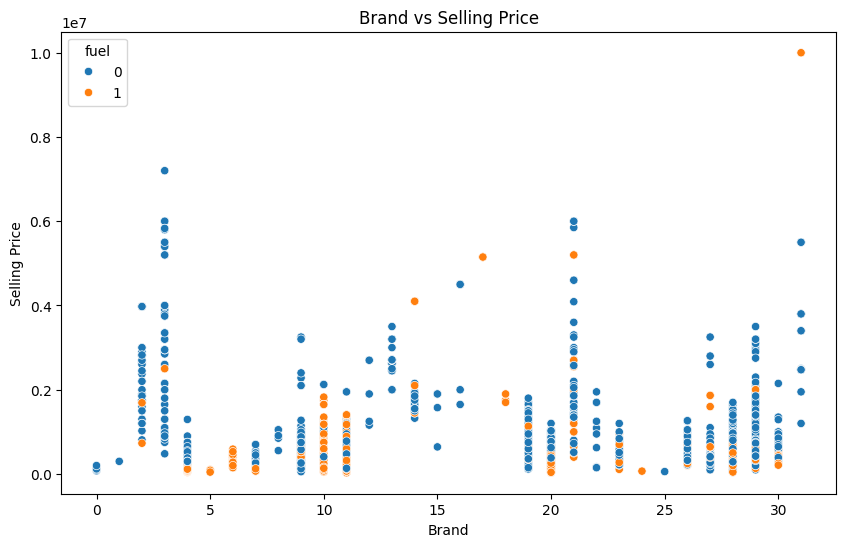

In [52]:
plt.figure(figsize=(10,6)) #Brand vs Selling Price

sns.scatterplot(
    x=df['brand'],
    y=df['selling_price'],
    hue=df['fuel']
)

plt.title('Brand vs Selling Price')
plt.xlabel('Brand')
plt.ylabel('Selling Price')
plt.show()

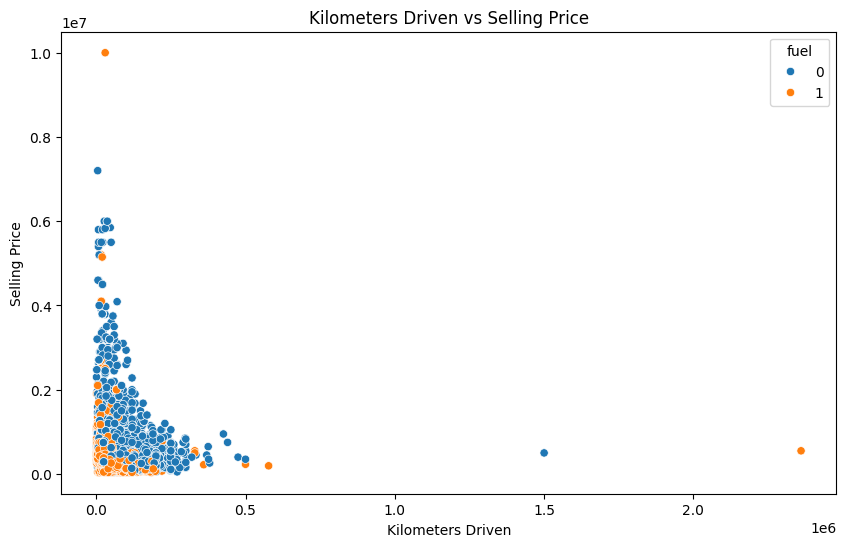

In [53]:
plt.figure(figsize=(10,6)) #Kilometers Driven vs Selling Price

sns.scatterplot(
    x=df['km_driven'],
    y=df['selling_price'],
    hue=df['fuel']
)

plt.title('Kilometers Driven vs Selling Price')
plt.xlabel('Kilometers Driven')
plt.ylabel('Selling Price')
plt.show()

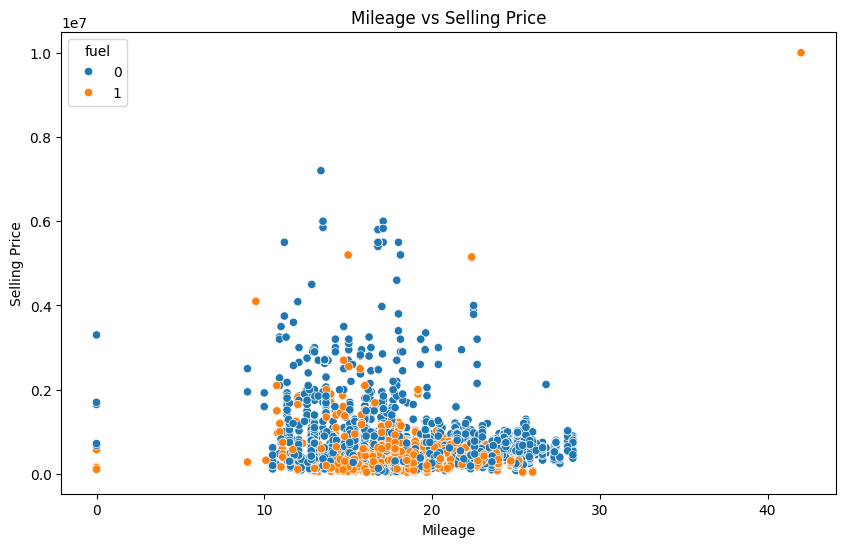

In [54]:
plt.figure(figsize=(10,6)) #Mileage vs Selling Price

sns.scatterplot(
    x=df['mileage'],
    y=df['selling_price'],
    hue=df['fuel']
)

plt.title('Mileage vs Selling Price')
plt.xlabel('Mileage')
plt.ylabel('Selling Price')
plt.show()

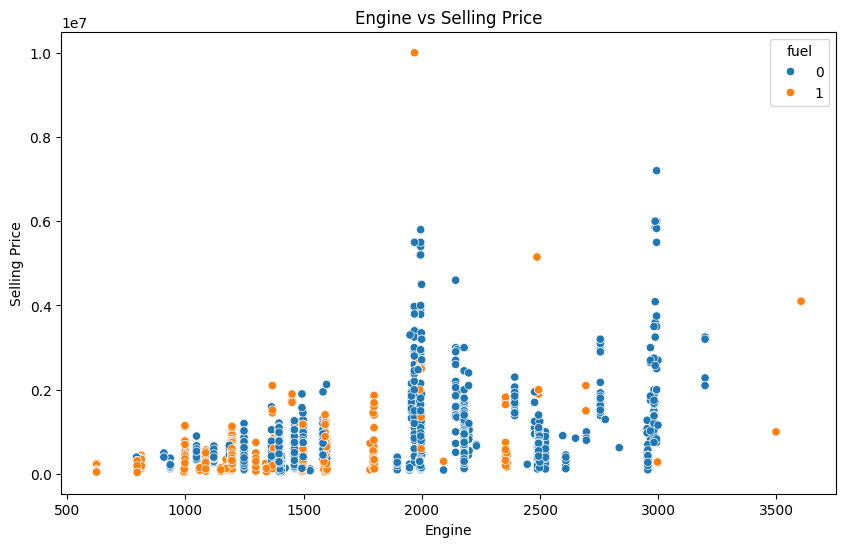

In [55]:
plt.figure(figsize=(10,6)) #Engine vs Selling Price

sns.scatterplot(
    x=df['engine'],
    y=df['selling_price'],
    hue=df['fuel']
)

plt.title('Engine vs Selling Price')
plt.xlabel('Engine')
plt.ylabel('Selling Price')
plt.show()

### **Correlation Matrix**

A correlation matrix is used to examine the relationship between the features and the target variable `selling_price`.

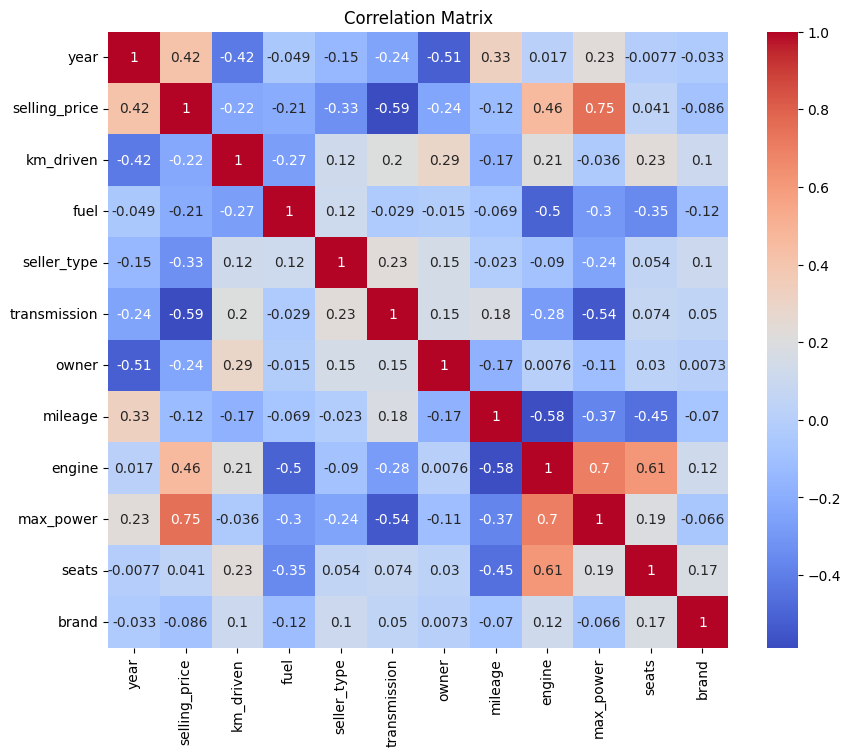

In [56]:
plt.figure(figsize=(10, 8))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Matrix')
plt.show()

### **Feature Selection**

Based on the exploratory data analysis and correlation matrix, `max_power`, `mileage`, `year`, and `brand` are selected as the input features for predicting the selling price.

In [57]:
X = df[['max_power', 'mileage', 'year', 'brand']]

In [58]:
X.head()

,max_power,mileage,year,brand
0,74.00,23.40,2014,20
1,103.52,21.14,2014,27
2,78.00,17.70,2006,10
3,90.00,23.00,2010,11
4,88.20,16.10,2007,20


The target variable `selling_price` is transformed using the natural logarithm to reduce skewness and improve the stability of the prediction model.

In [59]:
y = np.log(df['selling_price'])

In [60]:
y.head()

,selling_price
0,13.017003
1,12.821258
2,11.970350
3,12.323856
4,11.775290


### **Data Splitting**

The dataset is divided into training and testing sets. 70% of the data is used for training and 30% is reserved for testing the model on unseen data.

In [61]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=40
)

In [62]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (5619, 4)
X_test shape: (2409, 4)
y_train shape: (5619,)
y_test shape: (2409,)


## **Preprocessing**

The training and testing datasets are checked for missing values before model training.

In [63]:
X_train.isnull().sum() # Training features

,0
max_power,145
mileage,150
year,0
brand,0


In [64]:
X_test.isnull().sum() # Testing features

,0
max_power,63
mileage,64
year,0
brand,0


In [65]:
y_train.isnull().sum() # Training target

np.int64(0)

In [66]:
y_test.isnull().sum() # Testing target

np.int64(0)

### **Handling Missing Values**

The distributions of `max_power` and `mileage` are examined to determine an appropriate method for filling their missing values.

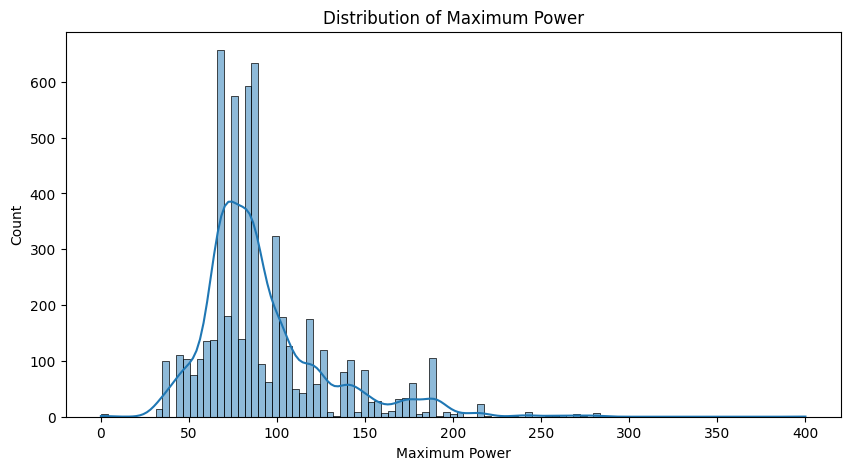

In [67]:
plt.figure(figsize=(10, 5))
sns.histplot(X_train['max_power'], kde=True)
plt.title('Distribution of Maximum Power')
plt.xlabel('Maximum Power')
plt.show()

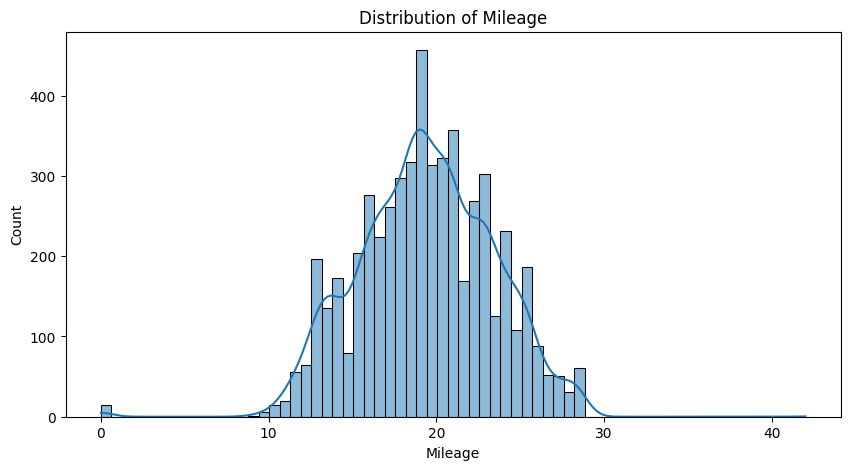

In [68]:
plt.figure(figsize=(10, 5))
sns.histplot(X_train['mileage'], kde=True)
plt.title('Distribution of Mileage')
plt.xlabel('Mileage')
plt.show()

#### **Calculating Imputation Values**

Since `max_power` is right-skewed, its missing values will be replaced using the median. Since `mileage` is more normally distributed, its missing values will be replaced using the mean.

In [69]:
max_power_median = X_train['max_power'].median()
mileage_mean = X_train['mileage'].mean()

print("Median of max_power:", max_power_median)
print("Mean of mileage:", mileage_mean)

Median of max_power: 82.85
Mean of mileage: 19.38717132931066


In [70]:
X_train['max_power'] = X_train['max_power'].fillna(max_power_median) #filling missing values in training set
X_train['mileage'] = X_train['mileage'].fillna(mileage_mean)

In [71]:
X_train.isnull().sum()

,0
max_power,0
mileage,0
year,0
brand,0


In [72]:
X_test['max_power'] = X_test['max_power'].fillna(max_power_median)
X_test['mileage'] = X_test['mileage'].fillna(mileage_mean)

In [73]:
X_test.isnull().sum()

,0
max_power,0
mileage,0
year,0
brand,0


In [74]:
print("Missing values in X_train:")
print(X_train.isnull().sum())

print("\nMissing values in X_test:")
print(X_test.isnull().sum())

print("\nMissing values in y_train:", y_train.isnull().sum())
print("Missing values in y_test:", y_test.isnull().sum())

Missing values in X_train:
max_power    0
mileage      0
year         0
brand        0
dtype: int64

Missing values in X_test:
max_power    0
mileage      0
year         0
brand        0
dtype: int64

Missing values in y_train: 0
Missing values in y_test: 0


All missing values in the selected features have now been handled. The imputation values were calculated only from the training dataset to avoid information leakage from the testing dataset.

### **Outlier Analysis**

Boxplots are used to identify possible outliers in the selected numerical features before model training.

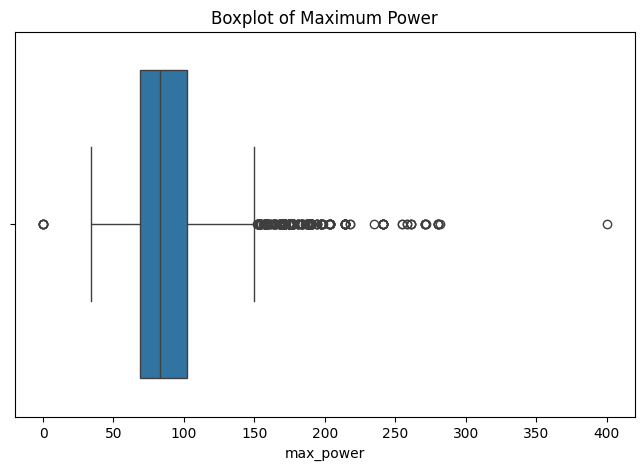

In [75]:
plt.figure(figsize=(8, 5))
sns.boxplot(x=X_train['max_power'])
plt.title('Boxplot of Maximum Power')
plt.show()

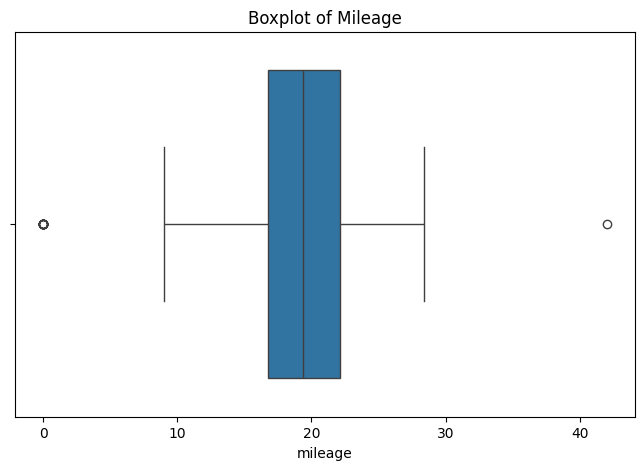

In [76]:
plt.figure(figsize=(8, 5))
sns.boxplot(x=X_train['mileage'])
plt.title('Boxplot of Mileage')
plt.show()

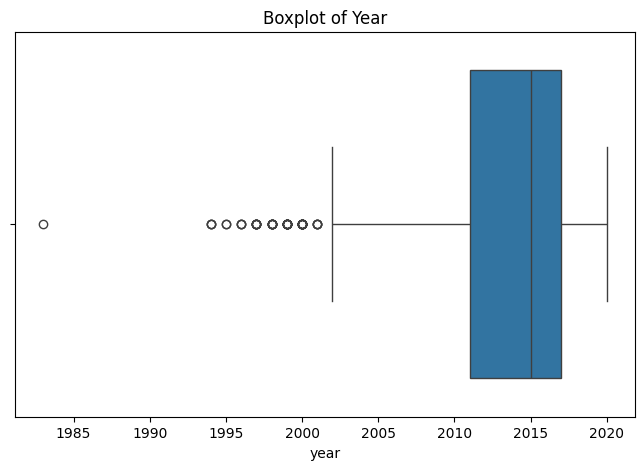

In [77]:
plt.figure(figsize=(8, 5))
sns.boxplot(x=X_train['year'])
plt.title('Boxplot of Year')
plt.show()

#### **Detecting Outliers Using IQR**

The Interquartile Range method is used to calculate the number and percentage of possible outliers in each numerical feature.

In [78]:
def find_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = data[
        (data[column] < lower_bound) |
        (data[column] > upper_bound)
    ]

    return outliers

In [79]:
for column in ['max_power', 'mileage', 'year']:
    outliers = find_outliers_iqr(X_train, column)

    percentage = (len(outliers) / len(X_train)) * 100

    print(f"{column}:")
    print(f"Number of outliers: {len(outliers)}")
    print(f"Percentage of outliers: {percentage:.2f}%")
    print()

max_power:
Number of outliers: 401
Percentage of outliers: 7.14%

mileage:
Number of outliers: 15
Percentage of outliers: 0.27%

year:
Number of outliers: 54
Percentage of outliers: 0.96%



#### **Outlier Decision**

The IQR method identified approximately 7.14% outliers in `max_power`, 0.27% in `mileage`, and 0.96% in `year`. These observations are retained because they may represent genuine variations in vehicle characteristics rather than incorrect data. For example, some vehicles naturally have significantly higher engine power than most cars. Removing these valid observations could reduce the model's ability to predict prices for uncommon vehicles.

### **Feature Scaling**

Min-Max scaling is applied to the continuous numerical features `max_power`, `mileage`, and `year`. The scaler is fitted only on the training data and then applied to the testing data to avoid data leakage.

In [84]:
from sklearn.preprocessing import MinMaxScaler

num_cols = ['max_power', 'mileage', 'year']

scaler = MinMaxScaler()

X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

In [85]:
X_train.head()

,max_power,mileage,year,brand
1661,0.31550,0.468333,0.864865,11
7024,0.16760,0.561667,0.837838,29
6774,0.11825,0.541429,0.837838,20
5686,0.19225,0.526190,0.810811,4
1912,0.25000,0.440238,0.918919,19


In [86]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(5619, 4)
(2409, 4)
(5619,)
(2409,)


## **Model Development and Experiment Tracking**

MLflow is used to record the parameters and evaluation metrics of different regression experiments so that the models can be compared systematically.

In [87]:
!pip install -q mlflow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 kB 2.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.5/50.5 kB 3.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.2/11.2 MB 85.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 73.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 59.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 265.9/265.9 kB 17.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 148.8/148.8 kB 10.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 212.0/212.0 kB 15.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 123.9/123.9 kB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.2/132.2 kB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 

In [88]:
import mlflow
import os

In [89]:
mlflow.set_experiment("car-price-regression-experiment")

2026/08/18 11:29:09 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/08/18 11:29:09 INFO mlflow.store.db.utils: Updating database tables
2026/08/18 11:29:12 INFO mlflow.tracking.fluent: Experiment with name 'car-price-regression-experiment' does not exist. Creating a new experiment.


<Experiment: artifact_location='/content/mlruns/1', creation_time=1787052552686, effective_trace_archival_retention=None, experiment_id='1', last_update_time=1787052552686, lifecycle_stage='active', name='car-price-regression-experiment', tags={}, trace_location=None, workspace='default'>

In [90]:
from sklearn.linear_model import LinearRegression

### **Custom Linear Regression**

A custom Linear Regression class is implemented to allow experimentation with different optimization methods, weight initialization techniques, polynomial features, momentum, and regularization.

In [93]:
from sklearn.model_selection import KFold
import numpy as np
import pandas as pd

class LinearRegression(object):

    kfold = KFold(n_splits=3)

    def __init__(
        self,
        regularization=None,
        lr=0.01,
        method='batch',
        init='xavier',
        polynomial=True,
        degree=2,
        use_momentum=True,
        momentum=0.5,
        num_epochs=500,
        batch_size=50,
        cv=kfold
    ):
        self.lr = lr
        self.num_epochs = num_epochs
        self.batch_size = batch_size
        self.method = method
        self.polynomial = polynomial
        self.degree = degree
        self.init = init
        self.use_momentum = use_momentum
        self.momentum = momentum
        self.prev_step = 0
        self.cv = cv
        self.regularization = regularization


    # Mean Squared Error
    def mse(self, ytrue, ypred):
        return ((ypred - ytrue) ** 2).sum() / ytrue.shape[0]


    # R-squared score
    def r2(self, ytrue, ypred):
        return 1 - (
            ((ytrue - ypred) ** 2).sum()
            /
            ((ytrue - ytrue.mean()) ** 2).sum()
        )


    # Average MSE from cross-validation
    def avgMSE(self):
        return np.mean(self.kfold_scores)


    # Average R2 from cross-validation
    def avgR2(self):
        return np.mean(self.kfold_r2)


    def fit(self, X_train, y_train):

        # Save feature names
        self.columns = X_train.columns

        # Apply polynomial transformation if required
        if self.polynomial:
            X_train = self._transform_features(X_train)
            print("Using Polynomial Features")
        else:
            X_train = X_train.to_numpy()
            print("Using Linear Features")

        y_train = y_train.to_numpy()

        self.kfold_scores = []
        self.kfold_r2 = []

        # Perform 3-fold cross-validation
        for fold, (train_idx, val_idx) in enumerate(self.cv.split(X_train)):

            X_cross_train = X_train[train_idx]
            y_cross_train = y_train[train_idx]

            X_cross_val = X_train[val_idx]
            y_cross_val = y_train[val_idx]

            # Initialize weights
            if self.init == 'xavier':

                n_features = X_cross_train.shape[1]

                lower = -(1 / np.sqrt(n_features))
                upper = 1 / np.sqrt(n_features)

                self.theta = np.random.rand(n_features)
                self.theta = lower + self.theta * (upper - lower)

            elif self.init == 'zero':

                self.theta = np.zeros(X_cross_train.shape[1])

            else:
                raise ValueError(
                    "Initialization must be 'xavier' or 'zero'"
                )

            # Reset momentum for each fold
            self.prev_step = 0

            # Training epochs
            for epoch in range(self.num_epochs):

                # Shuffle training data
                permutation = np.random.permutation(
                    X_cross_train.shape[0]
                )

                X_cross_train = X_cross_train[permutation]
                y_cross_train = y_cross_train[permutation]

                # Stochastic Gradient Descent
                if self.method == 'sto':

                    for i in range(X_cross_train.shape[0]):

                        X_batch = X_cross_train[i].reshape(1, -1)
                        y_batch = y_cross_train[i].reshape(1,)

                        self._train(X_batch, y_batch)

                # Mini-batch Gradient Descent
                elif self.method == 'mini':

                    for i in range(
                        0,
                        X_cross_train.shape[0],
                        self.batch_size
                    ):

                        X_batch = X_cross_train[
                            i:i+self.batch_size
                        ]

                        y_batch = y_cross_train[
                            i:i+self.batch_size
                        ]

                        self._train(X_batch, y_batch)

                # Batch Gradient Descent
                else:

                    self._train(
                        X_cross_train,
                        y_cross_train
                    )

            # Validation prediction
            yhat_val = self._predict(X_cross_val)

            val_mse = self.mse(
                y_cross_val,
                yhat_val
            )

            val_r2 = self.r2(
                y_cross_val,
                yhat_val
            )

            self.kfold_scores.append(val_mse)
            self.kfold_r2.append(val_r2)

            print(
                f"Fold {fold + 1}: "
                f"MSE = {val_mse:.4f}, "
                f"R2 = {val_r2:.4f}"
            )


    def _transform_features(self, X):

        X = (
            X.to_numpy()
            if hasattr(X, 'to_numpy')
            else X
        )

        # Bias column
        features = [
            np.ones((X.shape[0], 1))
        ]

        feature_names = ['bias']

        original_columns = self.columns

        # Original features
        features.append(X)
        feature_names.extend(original_columns)

        # Polynomial features
        for degree in range(
            2,
            self.degree + 1
        ):

            features.append(
                X ** degree
            )

            feature_names.extend(
                [
                    f"{column}^{degree}"
                    for column in original_columns
                ]
            )

        X_poly = np.hstack(features)

        self.poly_feature_names = feature_names

        return X_poly


    def _train(self, X, y):

        yhat = self._predict(X)

        m = X.shape[0]

        # Gradient
        grad = (
            (1 / m)
            * X.T
            @ (yhat - y)
        )

        # Add regularization if required
        if self.regularization is not None:

            grad += self.regularization.derivation(
                self.theta
            )

        # Gradient descent with momentum
        if self.use_momentum:

            step = self.lr * grad

            self.theta = (
                self.theta
                - step
                + self.momentum * self.prev_step
            )

            self.prev_step = step

        else:

            self.theta = (
                self.theta
                - self.lr * grad
            )

        return self.mse(y, yhat)


    def _predict(self, X):

        return X @ self.theta


    def predict(self, X):

        if self.polynomial:

            X = self._transform_features(X)

        else:

            X = (
                X.to_numpy()
                if hasattr(X, 'to_numpy')
                else X
            )

        return X @ self.theta

### **Regularization Methods**

Different regularization techniques are implemented to compare Normal Linear Regression, Ridge Regression, Lasso Regression, and Elastic Net Regression.

In [94]:
class LassoPenalty:

    def __init__(self, l):
        self.l = l

    def derivation(self, theta):
        return self.l * np.sign(theta)


class RidgePenalty:

    def __init__(self, l):
        self.l = l

    def derivation(self, theta):
        return self.l * 2 * theta


class ElasticPenalty:

    def __init__(
        self,
        l=0.1,
        l_ratio=0.5
    ):

        self.l = l
        self.l_ratio = l_ratio

    def derivation(self, theta):

        l1 = (
            self.l
            * self.l_ratio
            * np.sign(theta)
        )

        l2 = (
            self.l
            * (1 - self.l_ratio)
            * theta
        )

        return l1 + l2

In [95]:
class Normal(LinearRegression): #Regression models

    def __init__(
        self,
        l=0,
        lr=0.01,
        method='batch',
        init='xavier',
        polynomial=True,
        degree=2,
        use_momentum=True,
        momentum=0.5
    ):

        super().__init__(
            regularization=None,
            lr=lr,
            method=method,
            init=init,
            polynomial=polynomial,
            degree=degree,
            use_momentum=use_momentum,
            momentum=momentum
        )


class Ridge(LinearRegression):

    def __init__(
        self,
        l=0.1,
        lr=0.01,
        method='batch',
        init='xavier',
        polynomial=True,
        degree=2,
        use_momentum=True,
        momentum=0.5
    ):

        super().__init__(
            regularization=RidgePenalty(l),
            lr=lr,
            method=method,
            init=init,
            polynomial=polynomial,
            degree=degree,
            use_momentum=use_momentum,
            momentum=momentum
        )


class Lasso(LinearRegression):

    def __init__(
        self,
        l=0.1,
        lr=0.01,
        method='batch',
        init='xavier',
        polynomial=True,
        degree=2,
        use_momentum=True,
        momentum=0.5
    ):

        super().__init__(
            regularization=LassoPenalty(l),
            lr=lr,
            method=method,
            init=init,
            polynomial=polynomial,
            degree=degree,
            use_momentum=use_momentum,
            momentum=momentum
        )


class ElasticNet(LinearRegression):

    def __init__(
        self,
        l=0.1,
        lr=0.01,
        method='batch',
        init='xavier',
        polynomial=True,
        degree=2,
        use_momentum=True,
        momentum=0.5,
        l_ratio=0.5
    ):

        super().__init__(
            regularization=ElasticPenalty(
                l,
                l_ratio
            ),
            lr=lr,
            method=method,
            init=init,
            polynomial=polynomial,
            degree=degree,
            use_momentum=use_momentum,
            momentum=momentum
        )

In [98]:
X = df[['max_power', 'mileage', 'year', 'brand']]
y = np.log(df['selling_price'])

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=40
)

In [99]:
max_power_median = X_train['max_power'].median()
mileage_mean = X_train['mileage'].mean()

X_train['max_power'] = X_train['max_power'].fillna(max_power_median)
X_train['mileage'] = X_train['mileage'].fillna(mileage_mean)

X_test['max_power'] = X_test['max_power'].fillna(max_power_median)
X_test['mileage'] = X_test['mileage'].fillna(mileage_mean)

In [100]:
from sklearn.preprocessing import MinMaxScaler

scale_cols = ['max_power', 'mileage', 'year', 'brand']

scaler = MinMaxScaler()

X_train[scale_cols] = scaler.fit_transform(X_train[scale_cols])
X_test[scale_cols] = scaler.transform(X_test[scale_cols])

In [101]:
X_train.describe()

,max_power,mileage,year,brand
count,5619.000000,5619.000000,5619.000000,5619.000000
mean,0.228982,0.461599,0.832951,0.578079
std,0.088341,0.094159,0.109113,0.237225
min,0.000000,0.000000,0.000000,0.000000
25%,0.172500,0.400000,0.756757,0.354839
50%,0.207125,0.461599,0.864865,0.645161
75%,0.255000,0.526190,0.918919,0.645161
max,1.000000,1.000000,1.000000,1.000000


In [102]:
print(X_train.isnull().sum())
print()
print(X_test.isnull().sum())

max_power    0
mileage      0
year         0
brand        0
dtype: int64

max_power    0
mileage      0
year         0
brand        0
dtype: int64


### **Baseline Model**

A Normal Linear Regression model is first trained as a baseline using batch gradient descent, Xavier initialization, polynomial features, and momentum.

In [103]:
baseline_model = Normal(
    lr=0.01,
    method='mini',
    init='xavier',
    polynomial=True,
    degree=2,
    use_momentum=True,
    momentum=0.5
)

baseline_model.fit(
    X_train,
    y_train
)

Using Polynomial Features
Fold 1: MSE = 0.1225, R2 = 0.8382
Fold 2: MSE = 0.1203, R2 = 0.8252
Fold 3: MSE = 0.1174, R2 = 0.8241


In [104]:
print(
    "Average Cross-Validation MSE:",
    baseline_model.avgMSE()
)

print(
    "Average Cross-Validation R2:",
    baseline_model.avgR2()
)

Average Cross-Validation MSE: 0.12006504403141299
Average Cross-Validation R2: 0.8291781616348048


In [105]:
np.random.seed(42)

### **Comparing Regression Models**

Normal Linear Regression, Ridge, Lasso, and Elastic Net are trained using the same settings so their cross-validation performances can be compared fairly.

In [106]:
models = {
    'Normal': Normal(
        lr=0.01,
        method='mini',
        init='xavier',
        polynomial=True,
        degree=2,
        use_momentum=True,
        momentum=0.5
    ),

    'Ridge': Ridge(
        l=0.01,
        lr=0.01,
        method='mini',
        init='xavier',
        polynomial=True,
        degree=2,
        use_momentum=True,
        momentum=0.5
    ),

    'Lasso': Lasso(
        l=0.01,
        lr=0.01,
        method='mini',
        init='xavier',
        polynomial=True,
        degree=2,
        use_momentum=True,
        momentum=0.5
    ),

    'Elastic Net': ElasticNet(
        l=0.01,
        lr=0.01,
        method='mini',
        init='xavier',
        polynomial=True,
        degree=2,
        use_momentum=True,
        momentum=0.5,
        l_ratio=0.5
    )
}

In [107]:
results = [] # Training all four models

for name, model in models.items():

    print(f"\nTraining {name}")
    print("-" * 40)

    np.random.seed(42)

    model.fit(X_train, y_train)

    results.append({
        'Model': name,
        'Average MSE': model.avgMSE(),
        'Average R2': model.avgR2()
    })


Training Normal
----------------------------------------
Using Polynomial Features
Fold 1: MSE = 0.1219, R2 = 0.8390
Fold 2: MSE = 0.1211, R2 = 0.8241
Fold 3: MSE = 0.1177, R2 = 0.8236

Training Ridge
----------------------------------------
Using Polynomial Features
Fold 1: MSE = 0.3459, R2 = 0.5432
Fold 2: MSE = 0.3413, R2 = 0.5039
Fold 3: MSE = 0.3566, R2 = 0.4658

Training Lasso
----------------------------------------
Using Polynomial Features
Fold 1: MSE = 0.1328, R2 = 0.8246
Fold 2: MSE = 0.1352, R2 = 0.8035
Fold 3: MSE = 0.1357, R2 = 0.7967

Training Elastic Net
----------------------------------------
Using Polynomial Features
Fold 1: MSE = 0.1707, R2 = 0.7746
Fold 2: MSE = 0.1703, R2 = 0.7525
Fold 3: MSE = 0.1792, R2 = 0.7316


In [108]:
results_df = pd.DataFrame(results)

results_df

,Model,Average MSE,Average R2
0,Normal,0.120233,0.828903
1,Ridge,0.347947,0.504313
2,Lasso,0.134600,0.808239
3,Elastic Net,0.173371,0.752918


In [109]:
results_df.sort_values(
    by='Average MSE'
).reset_index(drop=True)

,Model,Average MSE,Average R2
0,Normal,0.120233,0.828903
1,Lasso,0.134600,0.808239
2,Elastic Net,0.173371,0.752918
3,Ridge,0.347947,0.504313


In [110]:
best_row = results_df.loc[
    results_df['Average MSE'].idxmin()
]

print("Best Model:", best_row['Model'])
print("Best Average MSE:", best_row['Average MSE'])
print("Best Average R2:", best_row['Average R2'])

Best Model: Normal
Best Average MSE: 0.12023260578997207
Best Average R2: 0.8289027543256827


#### **Initial Model Comparison**

Among the four regression approaches, Normal Linear Regression achieved the best cross-validation performance with an average MSE of approximately 0.1202 and an average R² of 0.8289. Lasso performed second best, while Elastic Net and Ridge produced lower R² scores. Therefore, Normal Linear Regression is selected for further experimentation and hyperparameter tuning.

### **Hyperparameter Experiments**

Different learning rates are tested using the Normal Linear Regression model to determine which value provides the best cross-validation performance.

In [112]:
learning_rates = [0.01, 0.001, 0.0001]

lr_results = []

for lr in learning_rates:

    np.random.seed(42)

    model = Normal(
        lr=lr,
        method='mini',
        init='xavier',
        polynomial=True,
        degree=2,
        use_momentum=True,
        momentum=0.5
    )

    print(f"\nLearning Rate: {lr}")
    model.fit(X_train, y_train)

    lr_results.append({
        'Learning Rate': lr,
        'Average MSE': model.avgMSE(),
        'Average R2': model.avgR2()
    })


Learning Rate: 0.01
Using Polynomial Features
Fold 1: MSE = 0.1219, R2 = 0.8390
Fold 2: MSE = 0.1211, R2 = 0.8241
Fold 3: MSE = 0.1177, R2 = 0.8236

Learning Rate: 0.001
Using Polynomial Features
Fold 1: MSE = 0.4965, R2 = 0.3444
Fold 2: MSE = 0.5580, R2 = 0.1890
Fold 3: MSE = 0.5085, R2 = 0.2383

Learning Rate: 0.0001
Using Polynomial Features
Fold 1: MSE = 1.2958, R2 = -0.7113
Fold 2: MSE = 1.5653, R2 = -1.2750
Fold 3: MSE = 1.3978, R2 = -1.0939


In [113]:
lr_results_df = pd.DataFrame(lr_results)

lr_results_df.sort_values(
    by='Average MSE'
).reset_index(drop=True)

,Learning Rate,Average MSE,Average R2
0,0.0100,0.120233,0.828903
1,0.0010,0.520990,0.257224
2,0.0001,1.419669,-1.026729


In [114]:
best_lr_row = lr_results_df.loc[
    lr_results_df['Average MSE'].idxmin()
]

best_lr = best_lr_row['Learning Rate']

print("Best Learning Rate:", best_lr)
print("MSE:", best_lr_row['Average MSE'])
print("R2:", best_lr_row['Average R2'])

Best Learning Rate: 0.01
MSE: 0.12023260578997207
R2: 0.8289027543256827


In [115]:
methods = ['batch', 'mini', 'sto']

method_results = []

for method in methods:

    np.random.seed(42)

    model = Normal(
        lr=best_lr,
        method=method,
        init='xavier',
        polynomial=True,
        degree=2,
        use_momentum=True,
        momentum=0.5
    )

    print(f"\nMethod: {method}")
    model.fit(X_train, y_train)

    method_results.append({
        'Method': method,
        'Average MSE': model.avgMSE(),
        'Average R2': model.avgR2()
    })


Method: batch
Using Polynomial Features
Fold 1: MSE = 1.2112, R2 = -0.5995
Fold 2: MSE = 1.4512, R2 = -1.1092
Fold 3: MSE = 1.3010, R2 = -0.9488

Method: mini
Using Polynomial Features
Fold 1: MSE = 0.1219, R2 = 0.8390
Fold 2: MSE = 0.1211, R2 = 0.8241
Fold 3: MSE = 0.1177, R2 = 0.8236

Method: sto
Using Polynomial Features
Fold 1: MSE = 0.1186, R2 = 0.8434
Fold 2: MSE = 0.1167, R2 = 0.8303
Fold 3: MSE = 0.1095, R2 = 0.8360


In [116]:
method_results_df = pd.DataFrame(method_results)

method_results_df.sort_values(
    by='Average MSE'
).reset_index(drop=True)

,Method,Average MSE,Average R2
0,sto,0.114932,0.836581
1,mini,0.120233,0.828903
2,batch,1.321133,-0.885827


In [117]:
best_method_row = method_results_df.loc[
    method_results_df['Average MSE'].idxmin()
]

best_method = best_method_row['Method']

print("Best Method:", best_method)
print("MSE:", best_method_row['Average MSE'])
print("R2:", best_method_row['Average R2'])

Best Method: sto
MSE: 0.11493180287506698
R2: 0.836581372892884


In [118]:
for _, row in results_df.iterrows():

    with mlflow.start_run(
        run_name=f"model_{row['Model']}"
    ):

        mlflow.log_param(
            "model",
            row['Model']
        )

        mlflow.log_metric(
            "average_mse",
            row['Average MSE']
        )

        mlflow.log_metric(
            "average_r2",
            row['Average R2']
        )

In [119]:
for _, row in lr_results_df.iterrows():

    with mlflow.start_run(
        run_name=f"lr_{row['Learning Rate']}"
    ):

        mlflow.log_param(
            "learning_rate",
            row['Learning Rate']
        )

        mlflow.log_metric(
            "average_mse",
            row['Average MSE']
        )

        mlflow.log_metric(
            "average_r2",
            row['Average R2']
        )

#### **Weight Initialization**

Xavier initialization and zero initialization are compared to determine which starting weights allow the model to achieve better cross-validation performance.

In [120]:
initializations = ['xavier', 'zero']

init_results = []

for init in initializations:

    np.random.seed(42)

    model = Normal(
        lr=best_lr,
        method=best_method,
        init=init,
        polynomial=True,
        degree=2,
        use_momentum=True,
        momentum=0.5
    )

    print(f"\nInitialization: {init}")

    model.fit(X_train, y_train)

    init_results.append({
        'Initialization': init,
        'Average MSE': model.avgMSE(),
        'Average R2': model.avgR2()
    })


Initialization: xavier
Using Polynomial Features
Fold 1: MSE = 0.1186, R2 = 0.8434
Fold 2: MSE = 0.1167, R2 = 0.8303
Fold 3: MSE = 0.1095, R2 = 0.8360

Initialization: zero
Using Polynomial Features
Fold 1: MSE = 0.1181, R2 = 0.8440
Fold 2: MSE = 0.1166, R2 = 0.8305
Fold 3: MSE = 0.1096, R2 = 0.8358


In [121]:
init_results_df = pd.DataFrame(init_results)

init_results_df.sort_values(
    by='Average MSE'
).reset_index(drop=True)

,Initialization,Average MSE,Average R2
0,zero,0.114777,0.836785
1,xavier,0.114932,0.836581


In [122]:
best_init_row = init_results_df.loc[
    init_results_df['Average MSE'].idxmin()
]

best_init = best_init_row['Initialization']

print("Best Initialization:", best_init)
print("MSE:", best_init_row['Average MSE'])
print("R2:", best_init_row['Average R2'])

Best Initialization: zero
MSE: 0.11477737436363854
R2: 0.8367847812259765


#### **Momentum Experiment**

The model is trained with and without momentum to determine whether momentum improves the gradient descent optimization process.

In [123]:
momentum_results = []

for use_momentum in [True, False]:

    np.random.seed(42)

    model = Normal(
        lr=best_lr,
        method=best_method,
        init=best_init,
        polynomial=True,
        degree=2,
        use_momentum=use_momentum,
        momentum=0.5
    )

    print(f"\nMomentum: {use_momentum}")

    model.fit(X_train, y_train)

    momentum_results.append({
        'Momentum': use_momentum,
        'Average MSE': model.avgMSE(),
        'Average R2': model.avgR2()
    })


Momentum: True
Using Polynomial Features
Fold 1: MSE = 0.1181, R2 = 0.8440
Fold 2: MSE = 0.1166, R2 = 0.8305
Fold 3: MSE = 0.1096, R2 = 0.8358

Momentum: False
Using Polynomial Features
Fold 1: MSE = 0.1167, R2 = 0.8459
Fold 2: MSE = 0.1171, R2 = 0.8299
Fold 3: MSE = 0.1086, R2 = 0.8373


In [124]:
momentum_results_df = pd.DataFrame(momentum_results)

momentum_results_df.sort_values(
    by='Average MSE'
).reset_index(drop=True)

,Momentum,Average MSE,Average R2
0,False,0.114117,0.837695
1,True,0.114777,0.836785


In [125]:
best_momentum_row = momentum_results_df.loc[
    momentum_results_df['Average MSE'].idxmin()
]

best_momentum = bool(
    best_momentum_row['Momentum']
)

print("Best Momentum Setting:", best_momentum)
print("MSE:", best_momentum_row['Average MSE'])
print("R2:", best_momentum_row['Average R2'])

Best Momentum Setting: False
MSE: 0.11411668716073038
R2: 0.8376950192965812


#### **Feature Transformation Experiment**

A first-degree model is compared with a second-degree polynomial model to determine whether adding squared features improves prediction performance.

In [126]:
degree_results = []

for degree in [1, 2]:

    np.random.seed(42)

    model = Normal(
        lr=best_lr,
        method=best_method,
        init=best_init,
        polynomial=True,
        degree=degree,
        use_momentum=best_momentum,
        momentum=0.5
    )

    print(f"\nPolynomial Degree: {degree}")

    model.fit(X_train, y_train)

    degree_results.append({
        'Degree': degree,
        'Average MSE': model.avgMSE(),
        'Average R2': model.avgR2()
    })


Polynomial Degree: 1
Using Polynomial Features
Fold 1: MSE = 0.1219, R2 = 0.8390
Fold 2: MSE = 0.1186, R2 = 0.8277
Fold 3: MSE = 0.1158, R2 = 0.8266

Polynomial Degree: 2
Using Polynomial Features
Fold 1: MSE = 0.1167, R2 = 0.8459
Fold 2: MSE = 0.1171, R2 = 0.8299
Fold 3: MSE = 0.1086, R2 = 0.8373


In [127]:
degree_results_df = pd.DataFrame(degree_results)

degree_results_df.sort_values(
    by='Average MSE'
).reset_index(drop=True)

,Degree,Average MSE,Average R2
0,2,0.114117,0.837695
1,1,0.118754,0.831082


In [128]:
best_degree_row = degree_results_df.loc[
    degree_results_df['Average MSE'].idxmin()
]

best_degree = int(
    best_degree_row['Degree']
)

print("Best Polynomial Degree:", best_degree)
print("MSE:", best_degree_row['Average MSE'])
print("R2:", best_degree_row['Average R2'])

Best Polynomial Degree: 2
MSE: 0.11411668716073038
R2: 0.8376950192965812


In [129]:
print("FINAL MODEL CONFIGURATION")
print("-------------------------")
print("Regression: Normal")
print("Learning Rate:", best_lr)
print("Optimization:", best_method)
print("Initialization:", best_init)
print("Momentum:", best_momentum)
print("Polynomial Degree:", best_degree)

FINAL MODEL CONFIGURATION
-------------------------
Regression: Normal
Learning Rate: 0.01
Optimization: sto
Initialization: zero
Momentum: False
Polynomial Degree: 2


In [130]:
def fit_final_model(model, X, y): #Training the best model

    model.columns = X.columns

    # Transform features
    X_data = model._transform_features(X)

    y_data = (
        y.to_numpy()
        if hasattr(y, 'to_numpy')
        else y
    )

    # Initialize weights
    if model.init == 'xavier':

        n_features = X_data.shape[1]

        lower = -(1 / np.sqrt(n_features))
        upper = 1 / np.sqrt(n_features)

        model.theta = np.random.rand(n_features)

        model.theta = (
            lower
            + model.theta * (upper - lower)
        )

    else:

        model.theta = np.zeros(
            X_data.shape[1]
        )

    model.prev_step = 0

    # Train using ALL training data
    for epoch in range(model.num_epochs):

        permutation = np.random.permutation(
            X_data.shape[0]
        )

        X_epoch = X_data[permutation]
        y_epoch = y_data[permutation]

        if model.method == 'sto':

            for i in range(X_epoch.shape[0]):

                model._train(
                    X_epoch[i].reshape(1, -1),
                    y_epoch[i].reshape(1,)
                )

        elif model.method == 'mini':

            for i in range(
                0,
                X_epoch.shape[0],
                model.batch_size
            ):

                model._train(
                    X_epoch[i:i + model.batch_size],
                    y_epoch[i:i + model.batch_size]
                )

        else:

            model._train(
                X_epoch,
                y_epoch
            )

    return model

In [131]:
final_model = Normal(
    lr=best_lr,
    method=best_method,
    init=best_init,
    polynomial=True,
    degree=best_degree,
    use_momentum=best_momentum,
    momentum=0.5
)

In [132]:
final_model = Normal(
    lr=best_lr,
    method=best_method,
    init=best_init,
    polynomial=True,
    degree=best_degree,
    use_momentum=best_momentum,
    momentum=0.5
)

np.random.seed(42)

final_model = fit_final_model(
    final_model,
    X_train,
    y_train
)

print("Final model training completed.")

Final model training completed.


### **Final Model Evaluation**

After selecting the best configuration using cross-validation on the training data, the final model is evaluated on the previously unseen testing dataset. Since the target variable was log-transformed during training, the predictions are transformed back to their original price scale using the exponential function.

In [133]:
pred_log = final_model.predict(X_test)

In [134]:
pred_price = np.exp(pred_log)

In [135]:
pred_log = final_model.predict(X_test)

pred_price = np.exp(pred_log)

actual_price = np.exp(
    y_test.to_numpy()
)

In [136]:
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

test_mse = mean_squared_error(
    actual_price,
    pred_price
)

test_rmse = np.sqrt(test_mse)

test_mae = mean_absolute_error(
    actual_price,
    pred_price
)

test_r2 = r2_score(
    actual_price,
    pred_price
)

print("FINAL TEST RESULTS")
print("------------------")
print(f"MSE:  {test_mse:,.2f}")
print(f"RMSE: {test_rmse:,.2f}")
print(f"MAE:  {test_mae:,.2f}")
print(f"R2:   {test_r2:.4f}")

FINAL TEST RESULTS
------------------
MSE:  127,072,859,741.65
RMSE: 356,472.80
MAE:  168,095.91
R2:   0.7999


In [137]:
comparison = pd.DataFrame({
    'Actual Price': actual_price,
    'Predicted Price': pred_price
})

comparison.head(10)

,Actual Price,Predicted Price
0,470000.0,499566.826985
1,300000.0,285346.397778
2,400000.0,591761.559372
3,375000.0,298858.910571
4,420000.0,389874.695801
5,650000.0,350913.180639
6,625000.0,659399.984103
7,60000.0,126299.264203
8,415000.0,519515.607780
9,750000.0,387549.511957


#### **Test Performance**

The final model achieved an R² score of approximately 0.80 on the unseen testing dataset, indicating that it explains about 80% of the variation in car selling prices. The Mean Absolute Error (MAE) was approximately 168,096, while the RMSE was approximately 356,473. The higher RMSE compared with MAE indicates that some vehicles have relatively large prediction errors, likely due to unusual or high-priced vehicles that are more difficult for the model to estimate accurately.

### **Actual vs Predicted Selling Prices**

A scatter plot is used to visually compare the model's predicted selling prices with the actual selling prices.

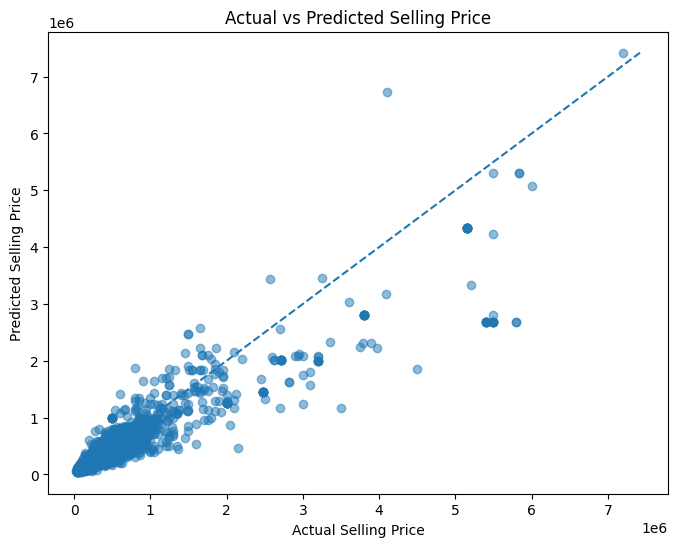

In [138]:
plt.figure(figsize=(8, 6))

plt.scatter(
    actual_price,
    pred_price,
    alpha=0.5
)

min_price = min(actual_price.min(), pred_price.min())
max_price = max(actual_price.max(), pred_price.max())

plt.plot(
    [min_price, max_price],
    [min_price, max_price],
    linestyle='--'
)

plt.xlabel('Actual Selling Price')
plt.ylabel('Predicted Selling Price')
plt.title('Actual vs Predicted Selling Price')

plt.show()

In [139]:
importance_df = pd.DataFrame({
    'Feature': final_model.poly_feature_names,
    'Coefficient': final_model.theta
})

importance_df

,Feature,Coefficient
0,bias,9.264641
1,max_power,7.007267
2,mileage,-0.851648
3,year,0.356711
4,brand,0.818549
5,max_power^2,-2.131058
6,mileage^2,1.048257
7,year^2,2.583752
8,brand^2,-0.702759


In [140]:
importance_df['Absolute Coefficient'] = (
    importance_df['Coefficient'].abs()
)

importance_df.sort_values(
    by='Absolute Coefficient',
    ascending=False
).reset_index(drop=True)

,Feature,Coefficient,Absolute Coefficient
0,bias,9.264641,9.264641
1,max_power,7.007267,7.007267
2,year^2,2.583752,2.583752
3,max_power^2,-2.131058,2.131058
4,mileage^2,1.048257,1.048257
5,mileage,-0.851648,0.851648
6,brand,0.818549,0.818549
7,brand^2,-0.702759,0.702759
8,year,0.356711,0.356711


In [141]:
sample = X_test.iloc[[0]]

sample

,max_power,mileage,year,brand
5422,0.3,0.286905,0.783784,0.612903


In [142]:
sample_log_prediction = final_model.predict(sample)

sample_price_prediction = np.exp(
    sample_log_prediction
)

print(
    "Predicted Selling Price:",
    sample_price_prediction[0]
)

Predicted Selling Price: 499566.826985378


In [143]:
actual_sample_price = np.exp(
    y_test.iloc[0]
)

print(
    "Actual Selling Price:",
    actual_sample_price
)

print(
    "Predicted Selling Price:",
    sample_price_prediction[0]
)

Actual Selling Price: 469999.99999999994
Predicted Selling Price: 499566.826985378


In [144]:
import os #saving the model

os.makedirs(
    '/content/model',
    exist_ok=True
)

In [145]:
import pickle

In [146]:
with open(
    '/content/model/car_price_model.pkl',
    'wb'
) as file:

    pickle.dump(
        final_model,
        file
    )

In [147]:
with open(
    '/content/model/scaler.pkl',
    'wb'
) as file:

    pickle.dump(
        scaler,
        file
    )

In [148]:
with open(
    '/content/model/brand_encoder.pkl',
    'wb'
) as file:

    pickle.dump(
        label_encoder_brand,
        file
    )

### **Final Experiment Tracking**

The final model configuration and test performance are recorded using MLflow for experiment tracking.

In [149]:
with mlflow.start_run(
    run_name='final_car_price_model'
):

    mlflow.log_param(
        'regression',
        'Normal'
    )

    mlflow.log_param(
        'learning_rate',
        best_lr
    )

    mlflow.log_param(
        'optimization',
        best_method
    )

    mlflow.log_param(
        'initialization',
        best_init
    )

    mlflow.log_param(
        'momentum',
        best_momentum
    )

    mlflow.log_param(
        'polynomial_degree',
        best_degree
    )

    mlflow.log_metric(
        'test_mse',
        test_mse
    )

    mlflow.log_metric(
        'test_rmse',
        test_rmse
    )

    mlflow.log_metric(
        'test_mae',
        test_mae
    )

    mlflow.log_metric(
        'test_r2',
        test_r2
    )

In [150]:
importance_sorted = importance_df.sort_values(
    by='Absolute Coefficient',
    ascending=False
).reset_index(drop=True)

importance_sorted

,Feature,Coefficient,Absolute Coefficient
0,bias,9.264641,9.264641
1,max_power,7.007267,7.007267
2,year^2,2.583752,2.583752
3,max_power^2,-2.131058,2.131058
4,mileage^2,1.048257,1.048257
5,mileage,-0.851648,0.851648
6,brand,0.818549,0.818549
7,brand^2,-0.702759,0.702759
8,year,0.356711,0.356711


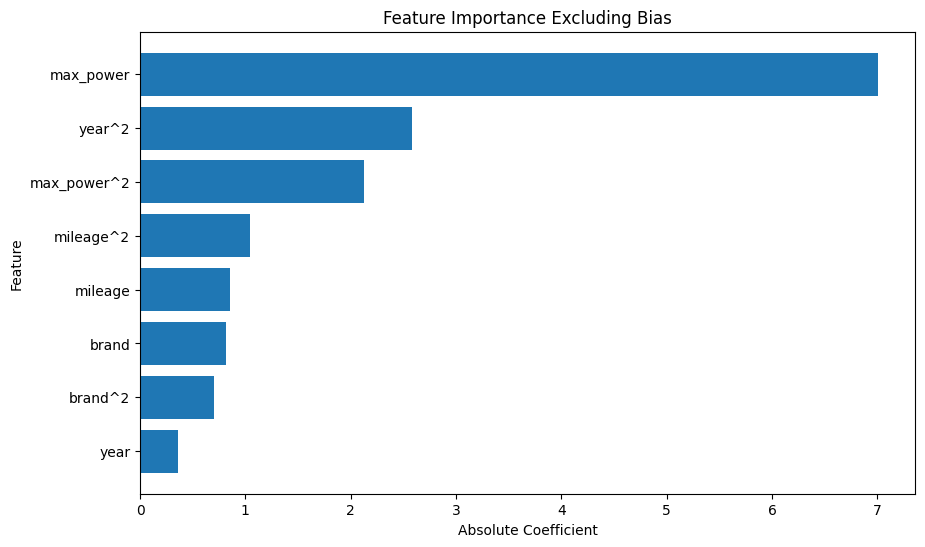

In [157]:
feature_importance = importance_sorted[
    importance_sorted['Feature'] != 'bias'
]

plt.figure(figsize=(10, 6))

plt.barh(
    feature_importance['Feature'],
    feature_importance['Absolute Coefficient']
)

plt.xlabel('Absolute Coefficient')
plt.ylabel('Feature')
plt.title('Feature Importance Excluding Bias')

plt.gca().invert_yaxis()
plt.show()

In [158]:
combined_importance = {
    'max_power':
        abs(final_model.theta[
            final_model.poly_feature_names.index('max_power')
        ]) +
        abs(final_model.theta[
            final_model.poly_feature_names.index('max_power^2')
        ]),

    'mileage':
        abs(final_model.theta[
            final_model.poly_feature_names.index('mileage')
        ]) +
        abs(final_model.theta[
            final_model.poly_feature_names.index('mileage^2')
        ]),

    'year':
        abs(final_model.theta[
            final_model.poly_feature_names.index('year')
        ]) +
        abs(final_model.theta[
            final_model.poly_feature_names.index('year^2')
        ]),

    'brand':
        abs(final_model.theta[
            final_model.poly_feature_names.index('brand')
        ]) +
        abs(final_model.theta[
            final_model.poly_feature_names.index('brand^2')
        ])
}

combined_importance_df = pd.DataFrame(
    list(combined_importance.items()),
    columns=['Feature', 'Combined Importance']
)

combined_importance_df = combined_importance_df.sort_values(
    by='Combined Importance',
    ascending=False
).reset_index(drop=True)

combined_importance_df

,Feature,Combined Importance
0,max_power,9.138324
1,year,2.940463
2,mileage,1.899905
3,brand,1.521308


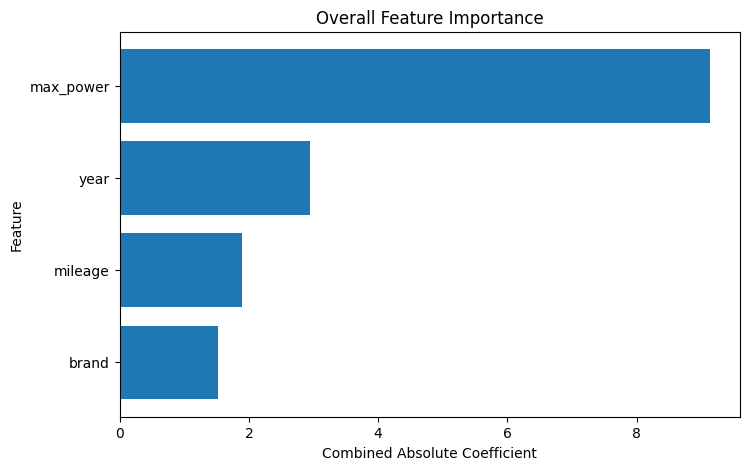

In [159]:
plt.figure(figsize=(8, 5))

plt.barh(
    combined_importance_df['Feature'],
    combined_importance_df['Combined Importance']
)

plt.xlabel('Combined Absolute Coefficient')
plt.ylabel('Feature')
plt.title('Overall Feature Importance')

plt.gca().invert_yaxis()
plt.show()

In [152]:
year_median = X.loc[X_train.index, 'year'].median()
brand_mode = X.loc[X_train.index, 'brand'].mode()[0]

imputation_values = {
    'max_power': max_power_median,
    'mileage': mileage_mean,
    'year': year_median,
    'brand': brand_mode
}

imputation_values

{'max_power': 82.85,
 'mileage': np.float64(19.38717132931066),
 'year': 2015.0,
 'brand': np.int64(20)}

In [153]:
with open(
    '/content/model/imputation_values.pkl',
    'wb'
) as file:
    pickle.dump(imputation_values, file)

In [154]:
os.listdir('/content/model')

['scaler.pkl',
 'car_price_model.pkl',
 'brand_encoder.pkl',
 'imputation_values.pkl']

In [155]:
with open(
    '/content/model/car_price_model.pkl',
    'rb'
) as file:
    loaded_model = pickle.load(file)

with open(
    '/content/model/scaler.pkl',
    'rb'
) as file:
    loaded_scaler = pickle.load(file)

with open(
    '/content/model/brand_encoder.pkl',
    'rb'
) as file:
    loaded_brand_encoder = pickle.load(file)

with open(
    '/content/model/imputation_values.pkl',
    'rb'
) as file:
    loaded_imputation_values = pickle.load(file)

print("All model components loaded successfully.")

All model components loaded successfully.


In [156]:
test_sample = X_test.iloc[[0]]

loaded_log_prediction = loaded_model.predict(
    test_sample
)

loaded_price_prediction = np.exp(
    loaded_log_prediction
)

print(
    f"Predicted Selling Price: {loaded_price_prediction[0]:,.2f}"
)

Predicted Selling Price: 499,566.83


### **Inference and Model Saving**

The final trained model and its preprocessing components were saved using Pickle and successfully loaded again for inference. This confirms that the model can be reused outside the notebook and integrated into the web-based car price prediction application.

# **Task 2: Report**

The experiments showed that Normal Linear Regression performed the best among the four regression approaches tested. It achieved an average cross-validation MSE of approximately **0.1202** and an average R² of approximately **0.8289**. Lasso Regression was the second-best model with an average R² of about **0.8082**, while Elastic Net and Ridge performed considerably worse. Ridge produced the lowest performance, with an average R² of approximately **0.5043**. This suggests that strong regularization was not particularly useful for the selected features in this dataset. After further hyperparameter experiments, the final configuration used a learning rate of 0.01, stochastic gradient descent, zero initialization, no momentum, and second-degree polynomial features.

The final model achieved an R² score of approximately 0.7999 on the unseen testing data, meaning that the model explained around 80% of the variation in car selling prices. The Mean Absolute Error was approximately 168,096 and the RMSE was approximately 356,473. The RMSE is noticeably higher than the MAE, which indicates that although many predictions were reasonably close to their actual prices, some vehicles had relatively large prediction errors. This can be expected because car prices can be affected by additional factors that were not included in the selected features, and some uncommon or expensive vehicles may be more difficult for the regression model to predict accurately.

The feature-importance analysis showed that `max_power` was the most influential feature, with a combined importance of approximately 9.14. This indicates that a vehicle's power has a strong relationship with its selling price. `year` was the second most influential feature with a combined importance of approximately 2.94, showing that newer and older vehicles have noticeably different market values. `mileage` had a smaller but still meaningful influence of approximately 1.90. `brand` had the lowest combined importance at approximately 1.52 among the four selected features. However, the importance of `brand` should be interpreted carefully because the categorical brands were converted into numerical values using Label Encoding. Overall, the second-degree polynomial model was useful because it allowed the model to represent nonlinear relationships between these features and selling price.

# **TASK 3: Deployment**

In [160]:
import os

os.makedirs(
    '/content/Car_Price_Project/app/code/model',
    exist_ok=True
)

print("App folders created.")

App folders created.


In [161]:
deployment_model = {
    'theta': final_model.theta,
    'degree': final_model.degree,
    'features': list(X_train.columns),
    'poly_feature_names': final_model.poly_feature_names
}

deployment_model

{'theta': array([ 9.26464076,  7.00726675, -0.85164801,  0.3567109 ,  0.81854873,
        -2.13105753,  1.04825679,  2.58375187, -0.70275928]),
 'degree': 2,
 'features': ['max_power', 'mileage', 'year', 'brand'],
 'poly_feature_names': ['bias',
  'max_power',
  'mileage',
  'year',
  'brand',
  'max_power^2',
  'mileage^2',
  'year^2',
  'brand^2']}

In [162]:
import pickle

with open(
    '/content/Car_Price_Project/app/code/model/model_data.pkl',
    'wb'
) as file:
    pickle.dump(deployment_model, file)

In [163]:
import shutil

shutil.copy(
    '/content/model/scaler.pkl',
    '/content/Car_Price_Project/app/code/model/scaler.pkl'
)

shutil.copy(
    '/content/model/brand_encoder.pkl',
    '/content/Car_Price_Project/app/code/model/brand_encoder.pkl'
)

shutil.copy(
    '/content/model/imputation_values.pkl',
    '/content/Car_Price_Project/app/code/model/imputation_values.pkl'
)

print("Model files copied successfully.")

Model files copied successfully.


In [164]:
os.listdir(
    '/content/Car_Price_Project/app/code/model'
)

['scaler.pkl', 'model_data.pkl', 'brand_encoder.pkl', 'imputation_values.pkl']

In [165]:
!pip install -q dash

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 89.1 MB/s eta 0:00:00


In [166]:
%%writefile /content/Car_Price_Project/app/code/requirements.txt
dash
numpy
pandas
scikit-learn
gunicorn

Writing /content/Car_Price_Project/app/code/requirements.txt


In [167]:
%%writefile /content/Car_Price_Project/app/code/app.py
import os
import pickle
import numpy as np
import pandas as pd

from dash import Dash, dcc, html, Input, Output, State
from dash.exceptions import PreventUpdate


# ---------------------------------------------------------
# Load model and preprocessing objects
# ---------------------------------------------------------

BASE_DIR = os.path.dirname(os.path.abspath(__file__))
MODEL_DIR = os.path.join(BASE_DIR, 'model')


with open(
    os.path.join(MODEL_DIR, 'model_data.pkl'),
    'rb'
) as file:
    model_data = pickle.load(file)


with open(
    os.path.join(MODEL_DIR, 'scaler.pkl'),
    'rb'
) as file:
    scaler = pickle.load(file)


with open(
    os.path.join(MODEL_DIR, 'brand_encoder.pkl'),
    'rb'
) as file:
    brand_encoder = pickle.load(file)


with open(
    os.path.join(MODEL_DIR, 'imputation_values.pkl'),
    'rb'
) as file:
    imputation_values = pickle.load(file)


theta = model_data['theta']
degree = model_data['degree']


# ---------------------------------------------------------
# Prediction function
# ---------------------------------------------------------

def predict_price(brand, year, mileage, max_power):

    # Handle missing brand
    if brand is None:
        brand_encoded = imputation_values['brand']
    else:
        brand_encoded = brand_encoder.transform([brand])[0]

    # Handle missing numerical values
    if year is None:
        year = imputation_values['year']

    if mileage is None:
        mileage = imputation_values['mileage']

    if max_power is None:
        max_power = imputation_values['max_power']


    # Keep the same feature order used during training
    sample = pd.DataFrame(
        [[max_power, mileage, year, brand_encoded]],
        columns=[
            'max_power',
            'mileage',
            'year',
            'brand'
        ]
    )


    # Apply the training scaler
    sample_scaled = scaler.transform(sample)


    # Build polynomial features:
    # bias + original values + squared values
    features = [
        np.ones((sample_scaled.shape[0], 1)),
        sample_scaled
    ]

    for d in range(2, degree + 1):
        features.append(sample_scaled ** d)

    sample_poly = np.hstack(features)


    # Predict log selling price
    pred_log = sample_poly @ theta

    # Transform back to original selling-price scale
    pred_price = np.exp(pred_log)

    return float(pred_price[0])


# ---------------------------------------------------------
# Dash application
# ---------------------------------------------------------

app = Dash(__name__)

server = app.server


brand_options = [
    {
        'label': brand,
        'value': brand
    }
    for brand in brand_encoder.classes_
]


app.layout = html.Div(

    style={
        'maxWidth': '700px',
        'margin': '40px auto',
        'fontFamily': 'Arial',
        'padding': '30px',
        'border': '1px solid #ddd',
        'borderRadius': '12px'
    },

    children=[

        html.H1(
            'Car Price Prediction',
            style={'textAlign': 'center'}
        ),

        html.P(
            '''
            Enter the available information about the car.
            You may leave a field blank if the information is
            unknown. Missing values will be automatically handled
            before prediction.
            '''
        ),


        html.Label('Brand'),

        dcc.Dropdown(
            id='brand-input',
            options=brand_options,
            placeholder='Select car brand',
            clearable=True
        ),


        html.Br(),

        html.Label('Year'),

        dcc.Input(
            id='year-input',
            type='number',
            placeholder='Example: 2017',
            style={'width': '100%'}
        ),


        html.Br(),
        html.Br(),

        html.Label('Mileage'),

        dcc.Input(
            id='mileage-input',
            type='number',
            placeholder='Example: 18.5',
            style={'width': '100%'}
        ),


        html.Br(),
        html.Br(),

        html.Label('Maximum Power'),

        dcc.Input(
            id='power-input',
            type='number',
            placeholder='Example: 100',
            style={'width': '100%'}
        ),


        html.Br(),
        html.Br(),

        html.Button(
            'Predict Selling Price',
            id='predict-button',
            n_clicks=0,
            style={
                'width': '100%',
                'padding': '12px',
                'fontSize': '16px',
                'cursor': 'pointer'
            }
        ),


        html.Div(
            id='prediction-output',
            style={
                'marginTop': '30px',
                'fontSize': '24px',
                'fontWeight': 'bold',
                'textAlign': 'center'
            }
        )
    ]
)


# ---------------------------------------------------------
# Prediction callback
# ---------------------------------------------------------

@app.callback(
    Output(
        'prediction-output',
        'children'
    ),

    Input(
        'predict-button',
        'n_clicks'
    ),

    State(
        'brand-input',
        'value'
    ),

    State(
        'year-input',
        'value'
    ),

    State(
        'mileage-input',
        'value'
    ),

    State(
        'power-input',
        'value'
    ),

    prevent_initial_call=True
)

def update_prediction(
    n_clicks,
    brand,
    year,
    mileage,
    max_power
):

    if not n_clicks:
        raise PreventUpdate

    try:

        predicted_price = predict_price(
            brand,
            year,
            mileage,
            max_power
        )

        return (
            f'Estimated Selling Price: '
            f'{predicted_price:,.2f}'
        )

    except Exception as error:

        return (
            f'Prediction error: {str(error)}'
        )


if __name__ == '__main__':

    app.run(
        host='0.0.0.0',
        port=8050,
        debug=False
    )

Writing /content/Car_Price_Project/app/code/app.py


In [174]:
import sys
import importlib

sys.path.insert(
    0,
    '/content/Car_Price_Project/app/code'
)

import app as car_app

In [175]:
from dash import jupyter_dash

jupyter_dash.infer_jupyter_proxy_config()

In [178]:
!wget -q https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64 -O /usr/local/bin/cloudflared
!chmod +x /usr/local/bin/cloudflared

In [179]:
!cloudflared --version

cloudflared version 2026.8.2 (built 2026-08-14-12:17 UTC)


In [180]:
import subprocess
import time
import re

process = subprocess.Popen(
    [
        "cloudflared",
        "tunnel",
        "--url",
        "http://127.0.0.1:8050"
    ],
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True
)

public_url = None

for _ in range(30):
    line = process.stdout.readline()

    if line:
        print(line.strip())

        match = re.search(
            r'https://[\w-]+\.trycloudflare\.com',
            line
        )

        if match:
            public_url = match.group(0)
            break

    time.sleep(1)

print("\nOpen this URL:", public_url)

2026-08-18T12:25:09Z INF Thank you for trying Cloudflare Tunnel. Doing so, without a Cloudflare account, is a quick way to experiment and try it out. However, be aware that these account-less Tunnels have no uptime guarantee, are subject to the Cloudflare Online Services Terms of Use (https://www.cloudflare.com/website-terms/), and Cloudflare reserves the right to investigate your use of Tunnels for violations of such terms. If you intend to use Tunnels in production you should use a pre-created named tunnel by following: https://developers.cloudflare.com/cloudflare-one/connections/connect-apps
2026-08-18T12:25:09Z INF Requesting new quick Tunnel on trycloudflare.com...
2026-08-18T12:25:14Z INF +--------------------------------------------------------------------------------------------+
2026-08-18T12:25:14Z INF |  Your quick Tunnel has been created! Visit it at (it may take some time to be reachable):  |
2026-08-18T12:25:14Z INF |  https://emperor-forget-theme-humanities.trycloudflare

In [181]:
%%writefile /content/Car_Price_Project/app/Dockerfile
FROM python:3.11-slim

WORKDIR /app

COPY code/requirements.txt .

RUN pip install --no-cache-dir -r requirements.txt

COPY code/ .

EXPOSE 8050

CMD ["gunicorn", "--bind", "0.0.0.0:8050", "app:server"]

Writing /content/Car_Price_Project/app/Dockerfile


In [182]:
%%writefile /content/Car_Price_Project/app/docker-compose.yaml
services:
  car-price-app:
    build: .
    ports:
      - "8050:8050"

Writing /content/Car_Price_Project/app/docker-compose.yaml


In [183]:
import os

for root, dirs, files in os.walk('/content/Car_Price_Project'):
    level = root.replace('/content/Car_Price_Project', '').count(os.sep)
    indent = '    ' * level

    print(f"{indent}{os.path.basename(root)}/")

    subindent = '    ' * (level + 1)

    for file in files:
        print(f"{subindent}{file}")

Car_Price_Project/
    app/
        docker-compose.yaml
        Dockerfile
        code/
            app.py
            requirements.txt
            model/
                scaler.pkl
                model_data.pkl
                brand_encoder.pkl
                imputation_values.pkl
            __pycache__/
                app.cpython-312.pyc


In [184]:
os.makedirs(
    '/content/Car_Price_Project/notebook',
    exist_ok=True
)

In [185]:
import shutil
import os

pycache_path = '/content/Car_Price_Project/app/code/__pycache__'

if os.path.exists(pycache_path):
    shutil.rmtree(pycache_path)

print("pycache removed.")

pycache removed.


In [186]:
os.listdir('/content/Car_Price_Project/app/code')

['app.py', 'requirements.txt', 'model']

In [187]:
shutil.copy(
    '/content/Cars.csv',
    '/content/Car_Price_Project/Cars.csv'
)

print("Cars.csv copied.")

Cars.csv copied.


In [189]:
import shutil

shutil.copy(
    '/content/A1_Predicting_Car_Price_126671.ipynb',
    '/content/Car_Price_Project/A1_Predicting_Car_Price_126671.ipynb'
)

print("Notebook copied!")

FileNotFoundError: [Errno 2] No such file or directory: '/content/A1_Predicting_Car_Price_126671.ipynb'